Loading dataset...
Dataset ready: (65377, 5)
Speed range: 0.09 - 99.99 m/s

Running ACO Feature Selection...


ACO:  10%|█         | 1/10 [00:07<01:03,  7.00s/it]

Iter 1: Best R² = 0.9922


ACO:  20%|██        | 2/10 [00:12<00:48,  6.08s/it]

Iter 2: Best R² = 0.9922


...

Iter 8: Best R² = 0.9922


ACO:  90%|█████████ | 9/10 [00:52<00:05,  5.65s/it]

Iter 9: Best R² = 0.9922


ACO: 100%|██████████| 10/10 [00:58<00:00,  5.81s/it]


Iter 10: Best R² = 0.9922

Selected features: ['Lat', 'Dist']
Selected 2/4 features

Training Models...

MODEL PERFORMANCE COMPARISON

SVR with ACO Features
Accuracy:  96.23%
Precision: 96.25%
Recall:    96.23%
F1-Score:  96.05%
RMSE:      0.9977
MAE:       0.6089
R²:        0.9981

Hybrid ACO + ELM
Accuracy:  95.25%
Precision: 95.18%
Recall:    95.25%
F1-Score:  95.10%
RMSE:      0.4386
MAE:       0.2271
R²:        0.9996

✅ Best model: ELM (R² = 0.9996)


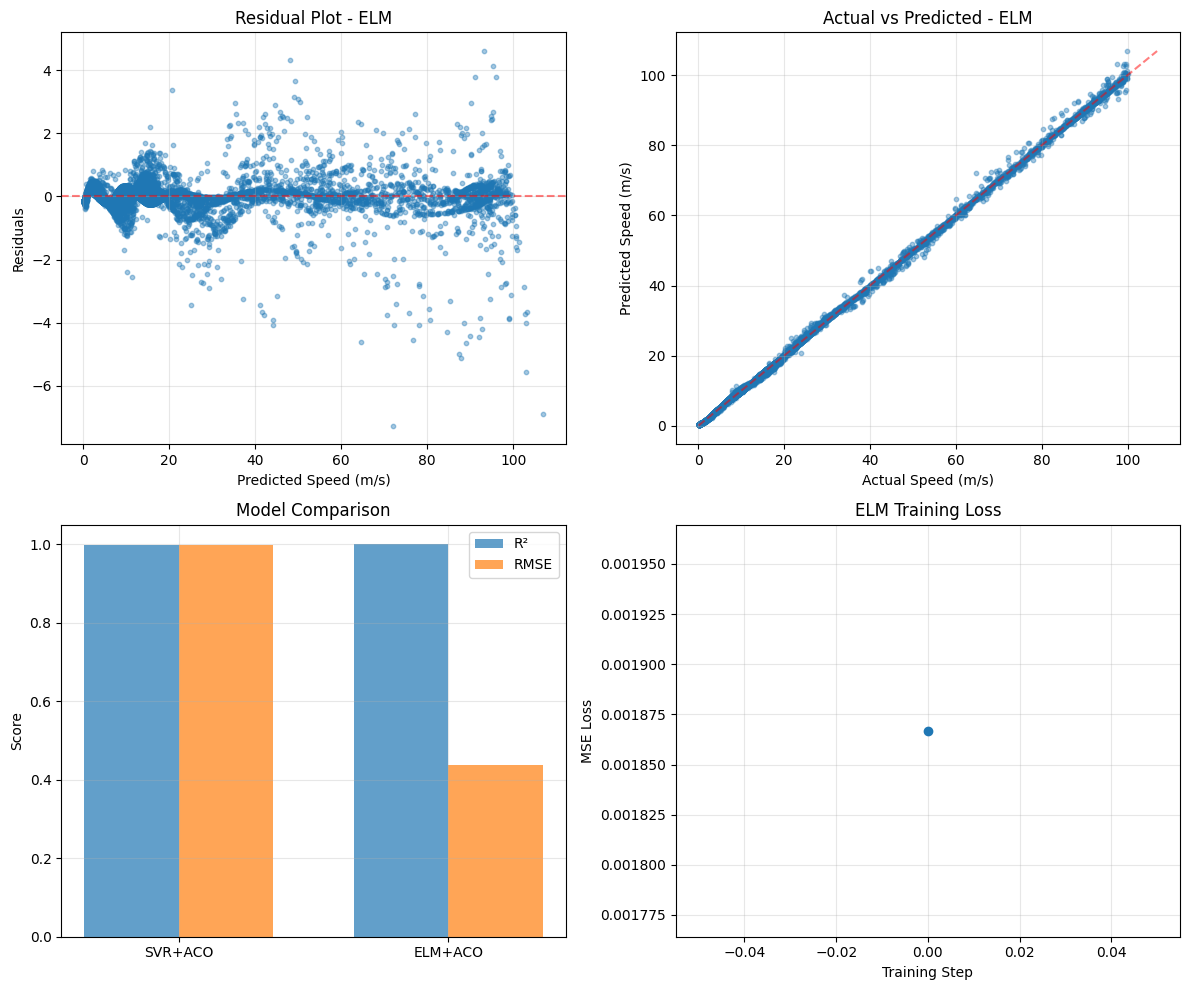


FILES SAVED:
- model.pkl (best trained model)
- preprocess.pkl (data preprocessing pipeline)
- aco_results.json (ACO feature selection results)
- results.json (all performance metrics)
- model_analysis.png (visualization plots)


In [ ]:

import os, glob, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.feature_selection import mutual_info_regression
from sklearn.svm import SVR

import joblib
import json

# ------------------- Configuration -------------------
RANDOM_STATE = 42
TARGET_COLUMN = "Speed"
TEST_SIZE = 0.2
DATA_FOLDER = "./dataset/Data"
N_FILES_READ = 80

# ------------------- Load Dataset -------------------
print("Loading dataset...")
plt_files = glob.glob(DATA_FOLDER + "/**/*.plt", recursive=True)
if not plt_files:
    raise FileNotFoundError("No .plt files found. Check dataset path.")

def read_plt(fpath):
    cols = ['Lat','Lon','Zero','Alt','Days','Date','Time']
    df = pd.read_csv(fpath, skiprows=6, header=None, names=cols)
    df.drop(columns=['Zero','Days'], inplace=True)
    df[['Lat','Lon','Alt']] = df[['Lat','Lon','Alt']].apply(pd.to_numeric, errors='coerce')
    df.dropna(subset=['Lat','Lon','Alt'], inplace=True)
    return df

dfs = [read_plt(f) for f in plt_files[:N_FILES_READ]]
df = pd.concat(dfs, ignore_index=True)

# Distance → Speed
def haversine(lat1, lon1, lat2, lon2):
    R = 6371e3
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * (2*np.arctan2(np.sqrt(a), np.sqrt(1 - a)))

df['PrevLat'] = df['Lat'].shift()
df['PrevLon'] = df['Lon'].shift()
df['Dist'] = haversine(df['PrevLat'], df['PrevLon'], df['Lat'], df['Lon']).fillna(0)
df['Speed'] = df['Dist']


df = df[df['Speed'] < 100]  
df = df[df['Speed'] > 0.01] 

df = df[['Lat','Lon','Alt','Dist','Speed']]
df.to_csv("dataset.csv", index=False)

print("Dataset ready:", df.shape)
print(f"Speed range: {df['Speed'].min():.2f} - {df['Speed'].max():.2f} m/s")

# ------------------- Preprocessing -------------------
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

y_log = np.log1p(y)  

num_cols = X.columns.tolist()

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", RobustScaler()) 
    ]), num_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

X_train_pp = preprocess.fit_transform(X_train)
X_test_pp = preprocess.transform(X_test)


joblib.dump(preprocess, "preprocess.pkl")


print("\nRunning ACO Feature Selection...")

base_model = SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.1)

mi = mutual_info_regression(X_train_pp, y_train)
mi = np.clip(mi, 1e-9, None) / np.max(mi)

n_feats = X_train_pp.shape[1]
N_ANTS, N_ITERS = 15, 10  
ALPHA, BETA, RHO = 1.0, 2.0, 0.3
MIN_SUBSET = max(2, int(0.6 * n_feats))  
tau = np.full(n_feats, 0.5)
rng = np.random.default_rng(RANDOM_STATE)

def score_subset(mask):
    if mask.sum() < MIN_SUBSET:
        return -1
    Xs = X_train_pp[:, mask][:2000]  # Use more samples
    ys = y_train[:2000]
    base_model.fit(Xs, ys)
    y_pred = base_model.predict(Xs)
    return r2_score(ys, y_pred)

best_score, best_mask = -np.inf, None
score_history = []

for it in tqdm(range(N_ITERS), desc="ACO"):
    iter_best = (-np.inf, None)
    
    for _ in range(N_ANTS):
        probs = (tau**ALPHA) * (mi**BETA)
        probs /= probs.sum()
        
        # Dynamic subset size
        k = rng.integers(int(0.5 * n_feats), int(0.9 * n_feats))
        idx = rng.choice(np.arange(n_feats), size=k, replace=False, p=probs)
        
        mask = np.zeros(n_feats, dtype=bool)
        mask[idx] = True
        s = score_subset(mask)
        
        if s > iter_best[0]:
            iter_best = (s, mask)

    tau = (1 - RHO) * tau
    if iter_best[1] is not None:
        tau[iter_best[1]] += 0.3 * iter_best[0]

    if iter_best[0] > best_score:
        best_score, best_mask = iter_best
    
    score_history.append(best_score)
    tqdm.write(f"Iter {it+1}: Best R² = {best_score:.4f}")

sel_idx = np.where(best_mask)[0]
selected_feats = np.array(num_cols)[sel_idx]

print("\nSelected features:", selected_feats.tolist())
print(f"Selected {len(sel_idx)}/{n_feats} features")


X_train_sel = X_train_pp[:, sel_idx]
X_test_sel = X_test_pp[:, sel_idx]


class ELM:
    def __init__(self, n_hidden=256, activation="tanh", random_state=42, C=1.0):
        self.n_hidden = n_hidden
        self.activation = activation
        self.C = C  
        np.random.seed(random_state)
        self.loss_history = []

    def _activate(self, X):
        if self.activation == "tanh":
            return np.tanh(X)
        elif self.activation == "relu":
            return np.maximum(0, X)
        elif self.activation == "sigmoid":
            return 1 / (1 + np.exp(-np.clip(X, -500, 500)))
        else:
            return X

    def fit(self, X, y):
        """
        Fit ELM model with ridge regression (L2 regularization)
        """
        n_samples, n_features = X.shape
        
        # Random input weights and biases
        self.W = np.random.randn(n_features, self.n_hidden) * np.sqrt(2.0 / n_features)
        self.b = np.random.uniform(-1, 1, self.n_hidden)
        
        
        H = self._activate(np.dot(X, self.W) + self.b)
        
        if n_samples >= self.n_hidden:
            I = np.eye(self.n_hidden)
            HTH = H.T @ H
            self.beta = np.linalg.solve(HTH + I/self.C, H.T @ y)
        else:
            I = np.eye(n_samples)
            HHT = H @ H.T
            self.beta = H.T @ np.linalg.solve(HHT + I/self.C, y)
        
        y_pred = self.predict(X)
        train_loss = mean_squared_error(y, y_pred)
        self.loss_history.append(train_loss)
        
        return self

    def predict(self, X):
        H = self._activate(np.dot(X, self.W) + self.b)
        return H @ self.beta

# ------------------- Train Final Models -------------------
print("\nTraining Models...")


svr = SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.05)
svr.fit(X_train_sel, y_train)
y_pred_svr_log = svr.predict(X_test_sel)


y_pred_svr = np.expm1(y_pred_svr_log)
y_test_original = np.expm1(y_test)


elm = ELM(n_hidden=256, activation="tanh", C=5.0)
elm.fit(X_train_sel, y_train)
y_pred_elm_log = elm.predict(X_test_sel)


y_pred_elm = np.expm1(y_pred_elm_log)

# ------------------- Evaluation -------------------
def evaluate(y_true_original, y_pred, y_pred_log, name):
    if len(y_pred_log.shape) > 0:
        rmse = math.sqrt(mean_squared_error(y_true_original, y_pred))
        mae = mean_absolute_error(y_true_original, y_pred)
        r2 = r2_score(y_true_original, y_pred)
        
        y_true_class = pd.cut(y_true_original, bins=5, labels=["Very Low", "Low", "Medium", "High", "Very High"])
        y_pred_class = pd.cut(pd.Series(y_pred), bins=5, labels=["Very Low", "Low", "Medium", "High", "Very High"])
        
        valid_mask = ~(y_true_class.isna() | y_pred_class.isna())
        y_true_class = y_true_class[valid_mask]
        y_pred_class = y_pred_class[valid_mask]
        
        if len(y_true_class) > 0:
            acc = accuracy_score(y_true_class, y_pred_class)
            prec = precision_score(y_true_class, y_pred_class, average="weighted", zero_division=0)
            rec = recall_score(y_true_class, y_pred_class, average="weighted", zero_division=0)
            f1 = f1_score(y_true_class, y_pred_class, average="weighted", zero_division=0)
        else:
            acc = prec = rec = f1 = 0
        
        print(f"\n{name}")
        print("=" * 40)
        print(f"Accuracy:  {acc*100:.2f}%")
        print(f"Precision: {prec*100:.2f}%")
        print(f"Recall:    {rec*100:.2f}%")
        print(f"F1-Score:  {f1*100:.2f}%")
        print(f"RMSE:      {rmse:.4f}")
        print(f"MAE:       {mae:.4f}")
        print(f"R²:        {r2:.4f}")
        print("=" * 40)
        
        return {
            'accuracy': acc*100,
            'precision': prec*100,
            'recall': rec*100,
            'f1': f1*100,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }
    return None

print("\n" + "="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)

results_svr = evaluate(y_test_original, y_pred_svr, y_pred_svr_log, "SVR with ACO Features")
results_elm = evaluate(y_test_original, y_pred_elm, y_pred_elm_log, "Hybrid ACO + ELM")

# ------------------- Save Best Model -------------------
if results_elm['r2'] > results_svr['r2']:
    joblib.dump(elm, "model.pkl")
    best_pred = y_pred_elm
    best_name = "ELM"
    print(f"\n✅ Best model: ELM (R² = {results_elm['r2']:.4f})")
else:
    joblib.dump(svr, "model.pkl")
    best_pred = y_pred_svr
    best_name = "SVR"
    print(f"\n✅ Best model: SVR (R² = {results_svr['r2']:.4f})")

results_dict = {
    'svr': results_svr,
    'elm': results_elm,
    'best_model': best_name,
    'selected_features': selected_feats.tolist(),
    'n_features_selected': len(sel_idx)
}

with open("results.json", "w") as f:
    json.dump(results_dict, f, indent=2)

# ------------------- Visualization -------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residual plot
axes[0,0].scatter(best_pred, y_test_original - best_pred, alpha=0.4, s=10)
axes[0,0].axhline(0, linestyle='--', color='red', alpha=0.5)
axes[0,0].set_xlabel("Predicted Speed (m/s)")
axes[0,0].set_ylabel("Residuals")
axes[0,0].set_title(f"Residual Plot - {best_name}")
axes[0,0].grid(True, alpha=0.3)

# Actual vs Predicted
axes[0,1].scatter(y_test_original, best_pred, alpha=0.4, s=10)
min_val = min(y_test_original.min(), best_pred.min())
max_val = max(y_test_original.max(), best_pred.max())
axes[0,1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
axes[0,1].set_xlabel("Actual Speed (m/s)")
axes[0,1].set_ylabel("Predicted Speed (m/s)")
axes[0,1].set_title(f"Actual vs Predicted - {best_name}")
axes[0,1].grid(True, alpha=0.3)

# Model comparison bar chart
models = ['SVR+ACO', 'ELM+ACO']
r2_scores = [results_svr['r2'], results_elm['r2']]
rmse_scores = [results_svr['rmse'], results_elm['rmse']]

x = np.arange(len(models))
width = 0.35

axes[1,0].bar(x - width/2, r2_scores, width, label='R²', alpha=0.7)
axes[1,0].bar(x + width/2, rmse_scores, width, label='RMSE', alpha=0.7)
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(models)
axes[1,0].set_ylabel('Score')
axes[1,0].set_title('Model Comparison')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Loss history (if available)
if hasattr(elm, 'loss_history'):
    axes[1,1].plot(elm.loss_history, marker='o')
    axes[1,1].set_xlabel('Training Step')
    axes[1,1].set_ylabel('MSE Loss')
    axes[1,1].set_title('ELM Training Loss')
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("FILES SAVED:")
print("- model.pkl (best trained model)")
print("- preprocess.pkl (data preprocessing pipeline)")
print("- aco_results.json (ACO feature selection results)")
print("- results.json (all performance metrics)")
print("- model_analysis.png (visualization plots)")
print("="*50)


COORDINATE RECONSTRUCTION — PREDICTED NEXT GPS POSITIONS

Showing first 20 of 13076 test samples:

 TimeStep  PredDist  PredLat   PredLon
        1    0.2884 40.00984 116.31493
        2    9.4508 39.99164 116.33115
        3    5.9361 39.89889 116.38943
        4    1.3987 40.00966 116.31520
        5    9.4344 40.00997 116.31561
        6    2.9709 40.01030 116.29688
        7    2.0822 40.00944 116.31554
        8   16.5085 40.00908 116.32173
        9    3.8849 39.98947 116.27348
       10    0.3496 40.00968 116.31520
       11   13.6736 39.99685 116.32225
       12   11.4578 39.90084 116.41127
       13   59.6127 39.93384 116.75826
       14    9.1277 40.00952 116.31610
       15    3.6841 40.01024 116.29698
       16    1.5357 40.01004 116.31548
       17    0.2532 40.00972 116.31521
       18   15.4326 40.04841 116.58068
       19   21.1118 40.00743 116.31732
       20   19.5470 39.99987 116.32762

--- Extended view (with anchor + bearing) ---
 TimeStep  PredDist  Bearing  Prev

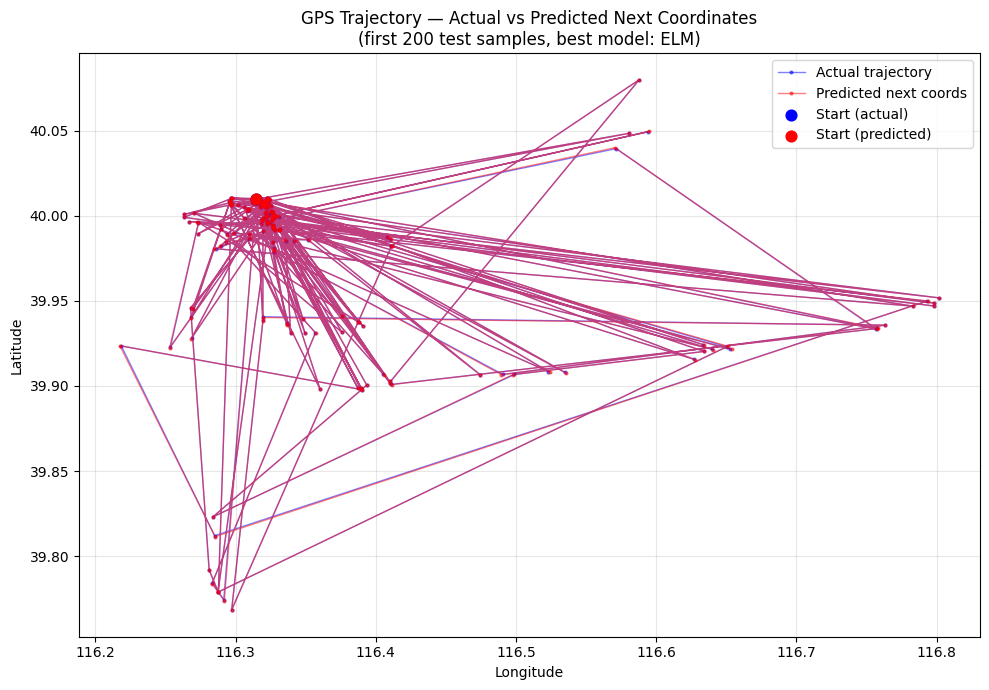

✅ Saved: predicted_trajectory.png


In [ ]:

import math
import numpy as np
import pandas as pd

# ------------------- Helper: Compute Bearing -------------------
def compute_bearing(lat1, lon1, lat2, lon2):
    """
    Compute the forward azimuth (bearing in degrees) from point 1 → point 2.
    Uses the spherical law of cosines for the forward bearing.
    """
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = math.sin(dlon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    bearing = math.degrees(math.atan2(x, y))
    return (bearing + 360) % 360  # Normalise to [0, 360)


# ------------------- Helper: Forward Geodesic Projection -------------------
def forward_geodesic(lat, lon, bearing_deg, distance_m):
    """
    Given an origin (lat, lon), a bearing (degrees), and a distance (metres),
    compute the destination coordinate using the spherical Earth formula
    (Vincenty approximation on a sphere of radius 6 371 000 m).

    Returns: (dest_lat, dest_lon) in decimal degrees.
    """
    R = 6_371_000.0 
    d = distance_m / R  
    theta = math.radians(bearing_deg)

    phi1 = math.radians(lat)
    lam1 = math.radians(lon)

    phi2 = math.asin(
        math.sin(phi1) * math.cos(d)
        + math.cos(phi1) * math.sin(d) * math.cos(theta)
    )
    lam2 = lam1 + math.atan2(
        math.sin(theta) * math.sin(d) * math.cos(phi1),
        math.cos(d) - math.sin(phi1) * math.sin(phi2)
    )

    return math.degrees(phi2), math.degrees(lam2)


# ------------------- Align Test-set indices with raw DataFrame -------------------

test_indices = X_test.index         
raw_test = df.loc[test_indices].reset_index(drop=True)   

pred_distances = best_pred  # shape (n_test,)


# ------------------- Build Coordinate Reconstruction Table -------------------
records = []

for i in range(len(raw_test)):
    # Current anchor point
    lat_t  = raw_test.loc[i, "Lat"]
    lon_t  = raw_test.loc[i, "Lon"]

   
    if i == 0:
       
        prev_idx = test_indices[0] - 1
        if prev_idx in df.index:
            lat_prev = df.loc[prev_idx, "Lat"]
            lon_prev = df.loc[prev_idx, "Lon"]
        else:
            lat_prev, lon_prev = lat_t, lon_t  
    else:
        lat_prev = raw_test.loc[i - 1, "Lat"]
        lon_prev = raw_test.loc[i - 1, "Lon"]

    # Bearing from previous → current point
    if (lat_prev == lat_t) and (lon_prev == lon_t):
        bearing = 0.0   
    else:
        bearing = compute_bearing(lat_prev, lon_prev, lat_t, lon_t)

    # Predicted distance for this time step
    pred_dist = float(pred_distances[i])

    # Project forward to estimate the NEXT position
    pred_lat, pred_lon = forward_geodesic(lat_t, lon_t, bearing, pred_dist)

    records.append({
        "TimeStep"  : i + 1,
        "PredDist"  : round(pred_dist, 4),
        "Bearing"   : round(bearing,   2),
        "PrevLat"   : round(lat_t,     5),
        "PrevLon"   : round(lon_t,     5),
        "PredLat"   : round(pred_lat,  5),
        "PredLon"   : round(pred_lon,  5),
        "ActualLat" : round(df.loc[test_indices[i], "Lat"], 5) if i + 1 < len(test_indices) else None,
        "ActualLon" : round(df.loc[test_indices[i], "Lon"], 5) if i + 1 < len(test_indices) else None,
    })

coord_df = pd.DataFrame(records)

# ------------------- Display Sample Output -------------------
DISPLAY_N = 20  

print("\n" + "=" * 75)
print("COORDINATE RECONSTRUCTION — PREDICTED NEXT GPS POSITIONS")
print("=" * 75)
print(f"\nShowing first {DISPLAY_N} of {len(coord_df)} test samples:\n")

preview = coord_df[["TimeStep", "PredDist", "PredLat", "PredLon"]].head(DISPLAY_N)
print(preview.to_string(index=False))

print("\n--- Extended view (with anchor + bearing) ---")
print(coord_df[["TimeStep", "PredDist", "Bearing",
                "PrevLat",  "PrevLon",
                "PredLat",  "PredLon"]].head(DISPLAY_N).to_string(index=False))

# ------------------- Coordinate Error Metrics -------------------
eval_df = coord_df.dropna(subset=["ActualLat", "ActualLon"]).copy()

if not eval_df.empty:
    def haversine_m(lat1, lon1, lat2, lon2):
        R = 6_371_000.0
        phi1, phi2 = math.radians(lat1), math.radians(lat2)
        dphi   = math.radians(lat2 - lat1)
        dlambda = math.radians(lon2 - lon1)
        a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
        return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    eval_df["CoordError_m"] = eval_df.apply(
        lambda r: haversine_m(r["PredLat"], r["PredLon"],
                              r["ActualLat"], r["ActualLon"]), axis=1
    )

    mae_coord  = eval_df["CoordError_m"].mean()
    rmse_coord = math.sqrt((eval_df["CoordError_m"] ** 2).mean())
    med_coord  = eval_df["CoordError_m"].median()

    print("\n" + "=" * 55)
    print("COORDINATE PREDICTION ERROR (vs actual next position)")
    print("=" * 55)
    print(f"  MAE  (mean geodesic error) : {mae_coord:>10.4f} m")
    print(f"  RMSE (geodesic)            : {rmse_coord:>10.4f} m")
    print(f"  Median geodesic error      : {med_coord:>10.4f} m")
    print("=" * 55)

# ------------------- Save Results -------------------
coord_df.to_csv("predicted_coordinates.csv", index=False)
print("\n✅ Saved: predicted_coordinates.csv")

# ------------------- Visualise Trajectory -------------------
N_PLOT = min(200, len(coord_df))
plot_df = coord_df.head(N_PLOT)
actual_lats = df.loc[test_indices[:N_PLOT], "Lat"].values
actual_lons = df.loc[test_indices[:N_PLOT], "Lon"].values

fig2, ax = plt.subplots(figsize=(10, 7))
ax.plot(actual_lons,           actual_lats,          "b.-", alpha=0.5,
        markersize=4,  linewidth=1,   label="Actual trajectory")
ax.plot(plot_df["PredLon"],    plot_df["PredLat"],   "r.-", alpha=0.5,
        markersize=4,  linewidth=1,   label="Predicted next coords")
ax.scatter(actual_lons[0],  actual_lats[0],   color="blue", zorder=5, s=60, label="Start (actual)")
ax.scatter(plot_df["PredLon"].iloc[0], plot_df["PredLat"].iloc[0],
           color="red",  zorder=5, s=60, label="Start (predicted)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"GPS Trajectory — Actual vs Predicted Next Coordinates\n(first {N_PLOT} test samples, best model: {best_name})")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("predicted_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: predicted_trajectory.png")
